In [ ]:
import os
import sys
import joblib
import re
import random

import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from collections import Counter
#from tqdm import tqdm

import torch

# Metadata

## флаги отладки, ускоряющие повторный прогон
**NB!:** при полном прогоне все флаги установлены в `True`

In [ ]:
running_in_cloud = False           # финальный прогон будет на VM в облаке без выполнения локальных сейвов
download_wikitext = False          # выбор источника датасета - интернет ресурсы библиотеки или локальный сейв

## глобальные параметры выполнения кода

In [3]:
# Фиксируем seed для воспроизводимости
random.seed(42)
torch.manual_seed(42)


seq_len_thres = 32             # длина последовательности токенов в объектах модели, на которых будет инференс
vocab_len_thres = 15000        # 3123 оптимальная длина словаря наиболее частых токенов-слов в корпусе текстов

# Этап 1.  Загрузка и подготовка данных


## loading dataset

In [4]:

if download_wikitext:
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
    if not running_in_cloud:
        joblib.dump(dataset, os.path.join('.','data','wikitext2dataset.joblib'))
else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are supposed to load data from the net when rinning in the cloud')
    else:
        dataset = joblib.load(os.path.join('.','data','wikitext2dataset.joblib'))

## first look at data

In [5]:
dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [6]:
dataset['train']

Dataset({
    features: ['text'],
    num_rows: 36718
})

In [7]:
print(type(dataset['train']['text']))                    # проверим тип данных
print('='*80, '\n')

print(dataset['train']['text'][:5])                      # топ списка
print('='*80, '\n')
      
for i, s in enumerate(dataset['train']['text'][:5]):   # выведем поэлементно с нумерацией
    if len(s) == 0:
        print(i, '  ', '<empty string>')                 # сделаем видимыми пустые строки
    else:
        print(i, '  ', s)
print('='*80, '\n')

for i, s in enumerate(dataset['train']['text'][:10]):
    s = s.strip('\n').strip()                        # похоже, строки списка содержат "\n" на конце и пробелы
    if len(s) == 0:
        print(i, '  | len in words =', str(len(s.split())).rjust(3), '|  ', '<empty string>')
    else:
        print(i, '  | len in words =', str(len(s.split())).rjust(3), '|  ', s)

<class 'list'>

['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the

## len-EDA

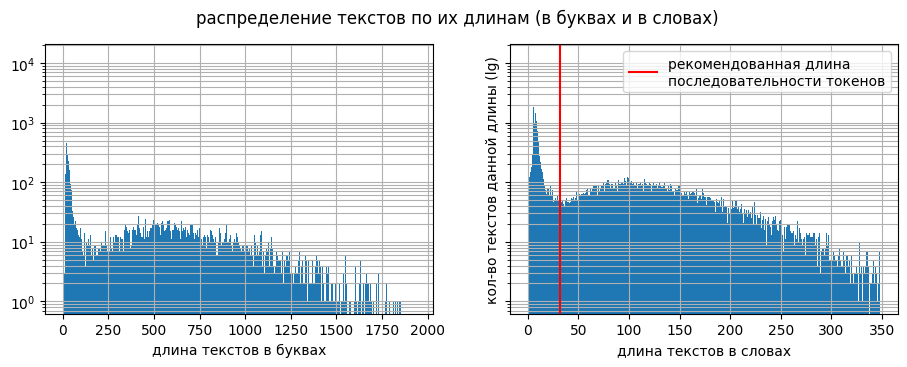

In [8]:
len_in_chars = [ len(el) for el in dataset['train']['text'] ]
len_in_words = [ len(el.split()) for el in dataset['train']['text'] ]

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11,3.5), sharey=True)

ax1.hist(len_in_chars, bins=range(max(len_in_chars)//2))
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_xlabel('длина текстов в буквах')

ax2.hist(len_in_words, bins=range(max(len_in_words)//2))
ax2.set_yscale('log')
ax2.grid(which='both')
ax2.set_xlabel('длина текстов в словах')
ax2.set_ylabel('кол-во текстов данной длины (lg)')
ax2.axvline(seq_len_thres, color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('распределение текстов по их длинам (в буквах и в словах)')
plt.show()

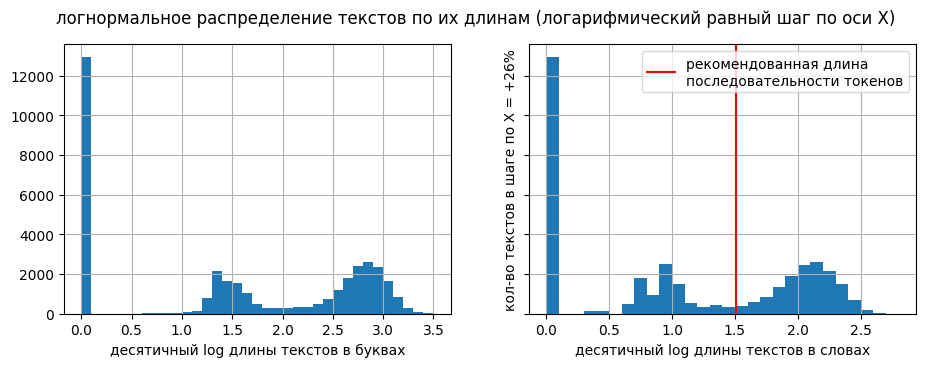

In [9]:
lg_len_in_chars = np.log(np.array(len_in_chars)+1) / np.log(10)   # если убрать прибавление 1, то код будет работать,
lg_len_in_words = np.log(np.array(len_in_words)+1) / np.log(10)   # но полностью исчезнет нулевая мода на графиках

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11,3.5), sharey=True)

ax1.hist(lg_len_in_chars, bins=[ 0.1*i for i in range(int(max(lg_len_in_chars)*10)+1)] )
ax1.grid(which='both')
ax1.set_xlabel('десятичный log длины текстов в буквах')

ax2.hist(lg_len_in_words, bins=[ 0.1*i for i in range(int(max(lg_len_in_words)*10)+1)] )
ax2.grid(which='both')
ax2.set_xlabel('десятичный log длины текстов в словах')
ax2.set_ylabel('кол-во текстов в шаге по X = +'+str(round((10**0.1-1)*100))+'%')
ax2.axvline(np.log(seq_len_thres)/np.log(10), color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('логнормальное распределение текстов по их длинам (логарифмический равный шаг по оси X)')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* В логнормальных координатах отчетливо выявляются три моды текстов:
  * совсем короткие, практически все они просто пустые
  * короткие - порядка десятка слов
  * полные - порядка сотни слов и длиннее
* `np.log(x)` справляется и с нулевым аргументом, выдавая минус бесконечность, которую не отрисует `matplotlib`, но мы добавляли к x +1 под логарифмом - чтобы вернуть на график все тексты.
* Рекомендуемая длина последовательности токенов 32 при предлагаемой токенизации словами идеально фильтрует только последнюю моду, удаляя две другие как шум - что разумно, так как статистика (и логика за ней) фразообразования в каждой моде, скорее всего, разная:  примерно также, как статистика продолжения фразы на заборе сильно отличается от таковой в художественном романе!

## raw preprocessing
теперь, когда минимальную длину текста в словах мы обосновали, можно проводить большую чистку данных 

In [10]:
def raw_preproc(raw_texts_list, len_thres):
    # удаляем слишком короткие тексты
    texts = [line for line in raw_texts_list if len(line.split()) >= len_thres]

    # функция для "чистки" текстов (из материалов урока)
    def clean_string(text):
        # приведение к нижнему регистру
        text = text.lower()
        # удаление всего, кроме латинских букв, цифр и пробелов
        text = re.sub(r'[^a-z0-9\s]', '', text)
        # удаление дублирующихся пробелов, удаление пробелов по краям
        text = re.sub(r'\s+', ' ', text).strip()
    
        return text

    # "чистим" тексты
    cleaned_texts_list = list(map(clean_string, texts))
    # повторно "обрезаем" коротких
    return [line for line in cleaned_texts_list if len(line.split()) >= len_thres]

### применяем функцию чистки к train/val/test спискам текстов

In [11]:
train_texts = raw_preproc(dataset['train']['text'], seq_len_thres)  
test_texts = raw_preproc(dataset['test']['text'], seq_len_thres)
val_texts = raw_preproc(dataset['validation']['text'], seq_len_thres)

len(train_texts), len(val_texts), len(test_texts)

(14344, 1519, 1726)

### оцениваем потери в данных после очистки

In [12]:
print('Осталось после чистки текстов:')
print('='*30)
print('train      ','val        ','test')
print('-'*30)
print(round(len(train_texts) / len(dataset['train']) *100,1), '%     ',
      round(len(val_texts) / len(dataset['validation']) *100,1), '%     ',
      round(len(test_texts) / len(dataset['test']) *100,1), '%')

Осталось после чистки текстов:
train       val         test
------------------------------
39.1 %      40.4 %      39.6 %


In [13]:
for i, s in enumerate(train_texts[:10]):
    print(i, '  | len =', str(len(s.split())).rjust(3), '|  ', s)

0   | len = 107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
1   | len =  82 |   the game began development in 2010 carrying over a large portion of the work done on valkyria chronicles ii while it retained the standard features of the series it also underwent multiple adjustments such as making the game more forgiving for series newcomers character designer raita honjou and composer hitosh

## собираем словарь для токенизации словами
для словаря не помешает объединить все данные

In [14]:
corpus = train_texts + val_texts + test_texts

counter = Counter()

for text in corpus:
    counter.update(text.split())

# список слов в порядке убывания частоты
words = [word for word, freq in counter.most_common()]

# список частот в том же порядке
freqs = [freq for word, freq in counter.most_common()]

print('Full dictionary length for word-tokenization was', len(freqs))
print('Top10 most frequent tokens are:', words[:10])

Full dictionary length for word-tokenization was 70075
Top10 most frequent tokens are: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', 'as', 'that']


### посмотрим как словарь распределился по частотам

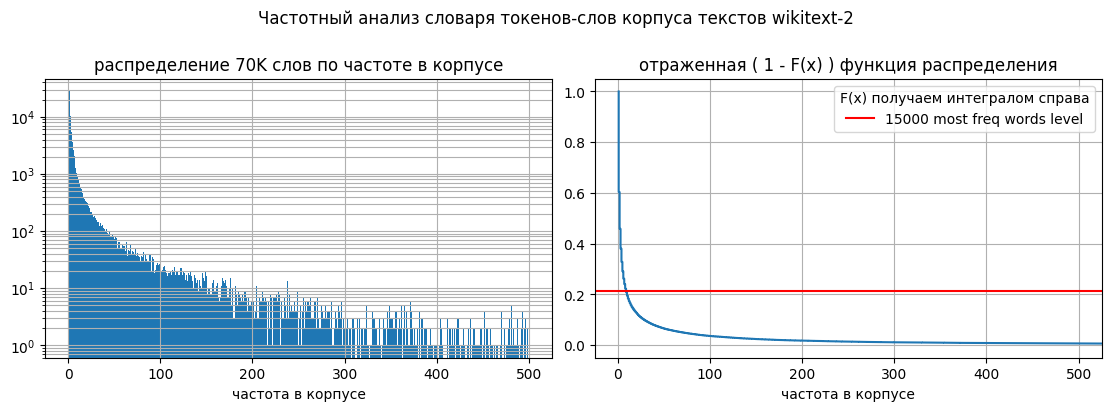

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True, layout='constrained')

ax1.hist( freqs, bins=range(500) )
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_title('распределение 70K слов по частоте в корпусе')
ax1.set_xlabel('частота в корпусе')

ax2.plot(freqs, [i/len(freqs) for i in range(1, len(freqs)+1)] )
ax2.axhline(vocab_len_thres/len(freqs), color='red', label=str(vocab_len_thres)+' most freq words level')
ax2.set_xlim(-25,525)
ax2.grid()
ax2.legend(title='F(x) получаем интегралом справа', loc='upper right')
ax2.set_title('отраженная ( 1 - F(x) ) функция распределения')
ax2.set_xlabel('частота в корпусе')

fig.suptitle('Частотный анализ словаря токенов-слов корпуса текстов wikitext-2\n')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* 30К слов из 70К встречаются во всем корпусе только 1 раз!
* 80% слов встречаются во всем корпусе реже 10 раз и навряд ли могут быть индивидуально запомнены моделью
* но замена их всех на OoV-токен сделает этот токен невероятно частым и он может начать попадать в рекомендации
* поэтому хотелось бы сделать его более естественно выглядящим в рекомендации модели - этакий джокер или слово-паразит: "типа", "этахрень", "well", "voila", "imho"

проверим "voila" - подойдет: его нет в корпусе!

In [16]:
'voila' in words, 'voil' in words       # слово могло обрезать французское написание последней буквы "voil`a"

(False, False)

### подбираем оптимальную отсечку по частоте
идея та же, что в оптимальном балансе precision-recall через максимум метрики f1

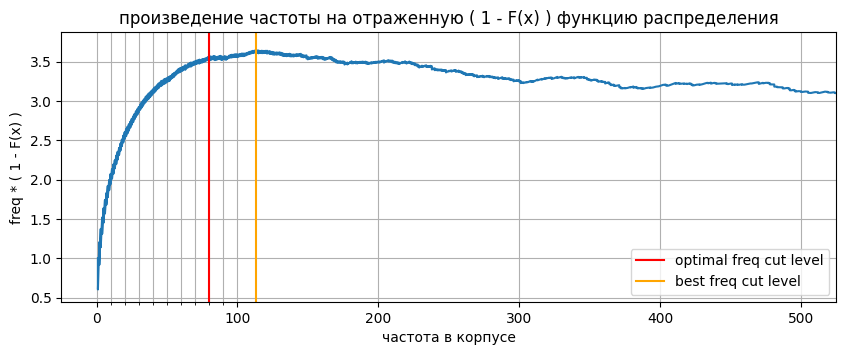

In [17]:
plt.figure(figsize=(10,3.5))
plt.plot(freqs, np.array(freqs) * np.array([i/len(freqs) for i in range(1, len(freqs)+1)]) )
plt.axvline(80, color='red', label='optimal freq cut level')
plt.axvline(113, color='orange', label='best freq cut level')
plt.xlim(-25,525)
plt.xticks(range(0,100,10), minor=True)
plt.grid(which='both')
plt.legend(loc='lower right')
plt.title('произведение частоты на отраженную ( 1 - F(x) ) функцию распределения')
plt.ylabel('freq * ( 1 - F(x) )')
plt.xlabel('частота в корпусе')


plt.show()

**ВЫВОДЫ ИЗ ГРАФИКА:**
* максимум площади под графиком отраженной функции распределения достигается при freq = 113
* однако, там широкое плато, поэтому за оптимальную отсечку принимаем частоту 80, где площадь начинает уже уверенно деградировать

In [18]:
print('Оптимальная длина словаря на данном корпусе текстов:   vocab_len_thres =', len([f for f in freqs if f >= 80]))

Оптимальная длина словаря на данном корпусе текстов:   vocab_len_thres = 3123


### ну и собственно словари: `words_encoder` & `words_decoder`

In [19]:
print('FYI: actual vocab_len_thres is set to:', vocab_len_thres)

FYI: actual vocab_len_thres is set to: 15000


In [20]:
words_encoder = dict(zip(words[:vocab_len_thres], range(vocab_len_thres)))
words_decoder = dict(zip(range(vocab_len_thres), words[:vocab_len_thres]))

# добавим voila
words_encoder['voila'] = vocab_len_thres
words_decoder[vocab_len_thres] = 'voila'

## texts encoding & "voila" substitution for OoV-words

### сперва нужно сделать замену редких на "voila"

In [21]:
black_list = set(words[vocab_len_thres:])

voila_train_texts, voila_val_texts, voila_test_texts = [], [], []
data_type = ['train data','val data','test data']

for i, (output, input) in enumerate([(voila_train_texts, train_texts),  
                                     (voila_val_texts, val_texts),      
                                     (voila_test_texts, test_texts)]):  
    print('Handling', data_type[i])
    
    for s in input:
        new_s_list = []
        for w in s.split():
            if w in black_list:
                new_s_list.append('voila')
            else:
                new_s_list.append(w)
        output.append(' '.join(new_s_list))
    
print('FYI: all done!')


len(voila_train_texts), len(voila_val_texts), len(voila_test_texts)

Handling train data
Handling val data
Handling test data
FYI: all done!


(14344, 1519, 1726)

In [22]:
for i in range(8):
    print(i, '  | len =', str(len(train_texts[i].split())).rjust(4), '|  ', train_texts[i])
    print(i, '  | len =', str(len(voila_train_texts[i].split())).rjust(4), '|  ', voila_train_texts[i])
    print('-'*80)

0   | len =  107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
0   | len =  107 |   voila no valkyria 3 voila chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and voila for the playstation portable released in january 2011 in japan it is the third game in the valkyria 